<a href="https://colab.research.google.com/github/SirLousy/LIS4693/blob/main/lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
import requests
import io

url = "https://raw.githubusercontent.com/SirLousy/LIS4693/refs/heads/main/lab-7/test.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))
df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [4]:
df.columns

Index(['Class Index', 'Title', 'Description'], dtype='object')

In [5]:
df_subset = df[['Description']].copy()
df_subset['ObjectId'] = df.index

df_subset.head()

,Description,ObjectId
0,Unions representing workers at Turner Newall...,0
1,"SPACE.com - TORONTO, Canada -- A second\team o...",1
2,AP - A company founded by a chemistry research...,2
3,AP - It's barely dawn when Mike Fitzpatrick st...,3
4,AP - Southern California's smog-fighting agenc...,4


I created a subset of the dataset using the Description column and added an ObjectId column to uniquely identify each row.

In [6]:
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", " ")
df_subset['Description'] = df_subset['Description'].str.casefold()

I cleaned the text by removing special characters and converting all text to lowercase.

In [8]:
sid = SentimentIntensityAnalyzer()

all_scores_list = []

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description'])

    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'],
            'sentiment_type': key,
            'sentiment_score': value
        })

t_df_all_types = pd.DataFrame(all_scores_list)

t_df_cleaned = t_df_all_types[
    t_df_all_types.sentiment_type == 'compound'
].drop_duplicates()

I used VADER sentiment analysis to calculate sentiment scores for each article. The compound score represents the overall sentiment.

In [9]:
df_output = pd.merge(df_subset, t_df_cleaned, on='ObjectId', how='inner')
df_output.head()

,Description,ObjectId,sentiment_type,sentiment_score
0,unions representing workers at turner newall...,0,compound,-0.5106
1,"space.com - toronto, canada -- a second\team o...",1,compound,0.5106
2,ap - a company founded by a chemistry research...,2,compound,0.8020
3,ap - it's barely dawn when mike fitzpatrick st...,3,compound,-0.1901
4,ap - southern california's smog-fighting agenc...,4,compound,0.0000


I used the ObjectId column as the common column to merge the original dataset with the sentiment scores.

In [10]:
df_output[['sentiment_score']].describe()

,sentiment_score
count,7600.000000
mean,0.028822
std,0.490085
min,-0.983300
25%,-0.361200
50%,0.000000
75%,0.421500
max,0.985300


Most of the sentiment scores are pretty close to neutral, with some slightly positive and some slightly negative values. The lowest scores get close to -1, which shows a few articles have strong negative tone, and the highest ones are near +1, meaning some are clearly positive. But overall, most of the articles stay around neutral since news is usually just reporting information rather than showing strong opinions.



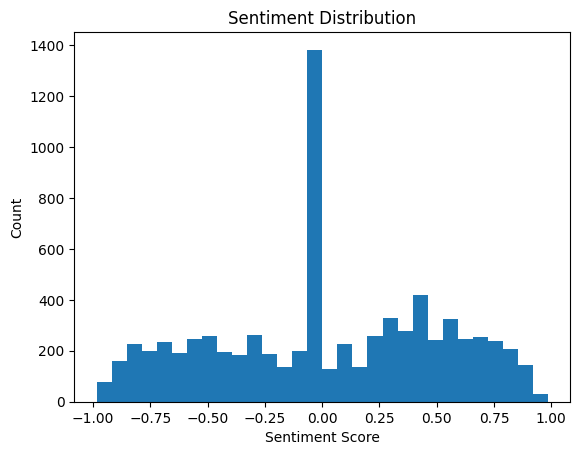

In [11]:
plt.hist(df_output['sentiment_score'], bins=30)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.show()

The histogram shows that most sentiment scores are clustered around neutral, with fewer strong positive or negative values.

<Axes: xlabel='sentiment_score'>

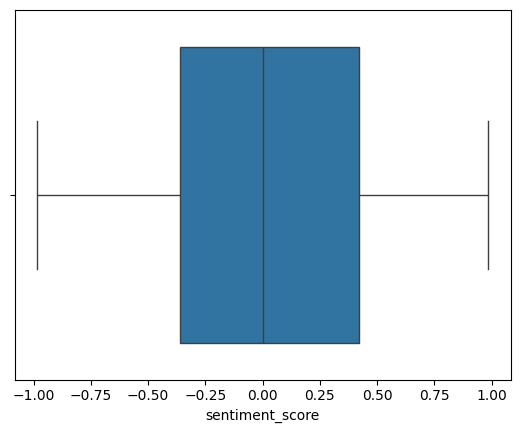

In [12]:
import seaborn as sns

sns.boxplot(x=df_output['sentiment_score'])

The boxplot shows the distribution of sentiment scores, with most values near the center and a few outliers on both ends

This lab went well once I understood how to use VADER for sentiment analysis. Cleaning the text and generating sentiment scores was straightforward. One challenge was understanding how the loop worked to calculate the sentiment scores and how the data was merged back together.
Sentiment analysis could be useful in my future work by analyzing user feedback, support tickets, or reviews to better understand user experiences and identify common issues.